# AGHRI 3D LiDAR Human Tracking Benchmark
### Comparing GT Oracle vs. PointPillars Detections across Three Agri-Human Scenarios

---

This notebook analyses the 3D multi-object tracking benchmark built on LiDAR point-cloud data from three agricultural human-presence scenarios.  
Two detection inputs are evaluated:
- **GT Oracle** — ground-truth bounding boxes fed directly as detections (perfect recall, upper-bound baseline)
- **PointPillars** — predictions from a PointPillars 3D detector fine-tuned on the AGHRI dataset

Three trackers are benchmarked:
- **AB3DMOT** — Kalman-filter tracker with Hungarian assignment and BEV IoU matching
- **SimpleTrack** — two-stage matching with high/low confidence separation
- **CenterPoint** — velocity-based greedy centre-distance tracker (no Kalman filter)

| Scenario | People | Setting | Occlusion Level |
|---|---|---|---|
| **Footpath** | 1 | Open outdoor footpath | Low |
| **In-Straw** | ~3 | Indoor straw environment, picking activity | Medium |
| **Out-Vine** | 4 | Outdoor vineyard, position swapping & walking | High |

**Metrics reported:** MOTA · MOTP · IDF1 · IDP · IDR · Precision · Recall · ID Switches · Mostly Tracked · HOTA · DetA · AssA

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

# Scenario palette -- ordered by difficulty
SCEN_ORDER  = ['footpath', 'in_straw', 'out_vine']
SCEN_LABELS = ['Footpath\n(Low Occlusion)', 'In-Straw\n(Medium Occlusion)', 'Out-Vine\n(High Occlusion)']
SCEN_COLORS = ['#4CAF50', '#FF9800', '#F44336']
SCEN_PAL    = dict(zip(SCEN_ORDER, SCEN_COLORS))

# Source palette
SRC_ORDER  = ['gt', 'pointpillars_aghri']
SRC_LABELS = ['GT Oracle', 'PointPillars']
SRC_COLORS = ['#1B5E20', '#1565C0']
SRC_PAL    = dict(zip(SRC_ORDER, SRC_COLORS))

# Tracker palette
TRK_ORDER  = ['ab3dmot', 'simpletrack', 'centerpoint']
TRK_LABELS = ['AB3DMOT', 'SimpleTrack', 'CenterPoint']
TRK_COLORS = ['#7B1FA2', '#F57F17', '#0277BD']
TRK_PAL    = dict(zip(TRK_ORDER, TRK_COLORS))

print('Setup complete')

Setup complete


## 1  Data Loading & Overview

In [18]:
df = pd.read_csv(
    'D:/AOC/agri-human-dataset-benchmark/3d-tracking/reports/summary/tracker_suite/suite_summary.csv'
)

# Derived columns
df['scenario'] = df['scene'].apply(
    lambda x: 'footpath' if 'footpath' in x
              else ('in_straw' if 'in_straw' in x else 'out_vine')
)

# Percentage forms
for col in ['idf1', 'idp', 'idr', 'precision', 'recall', 'mota', 'hota', 'deta', 'assa']:
    if col in df.columns:
        df[col + '_pct'] = df[col] * 100

# Readable labels
df['source_label']  = df['source'].map(dict(zip(SRC_ORDER, SRC_LABELS)))
df['tracker_label'] = df['tracker'].map(dict(zip(TRK_ORDER, TRK_LABELS)))

# Split for convenience
df_gt  = df[df['source'] == 'gt'].copy()
df_pp  = df[df['source'] == 'pointpillars_aghri'].copy()

print(f'Total rows: {len(df)}  |  '
      f'Sources: {df["source"].nunique()}  |  '
      f'Trackers: {df["tracker"].nunique()}  |  '
      f'Scenarios: {df["scenario"].nunique()}')
print(f'GT rows: {len(df_gt)}  |  PointPillars rows: {len(df_pp)}')
print()

# Dataset overview table
seq_info = (
    df_gt.drop_duplicates('scene')
    .groupby('scenario')
    .agg(Frames=('num_frames', 'first'))
    .reset_index()
)
# People count from mostly_tracked (GT oracle, best tracker gives most complete picture)
people = df_gt[df_gt['tracker'] == 'centerpoint'].groupby('scenario')['mostly_tracked'].first()
seq_info['People']    = seq_info['scenario'].map(people)
seq_info['Occlusion'] = seq_info['scenario'].map(
    {'footpath': 'Low', 'in_straw': 'Medium', 'out_vine': 'High'}
)
seq_info.index = seq_info['scenario'].map(
    {'footpath': 'Footpath', 'in_straw': 'In-Straw', 'out_vine': 'Out-Vine'}
)
display(
    seq_info[['Frames', 'People', 'Occlusion']]
    .style.set_caption('Table 1 -- Dataset Sequences')
    .format({'Frames': '{:,d}', 'People': '{:.0f}'})
)

Total rows: 18  |  Sources: 2  |  Trackers: 3  |  Scenarios: 3
GT rows: 9  |  PointPillars rows: 9



,Frames,People,Occlusion
scenario,,,
Footpath,200,1,Low
In-Straw,126,3,Medium
Out-Vine,276,4,High


## 2  Dataset Structure -- Scenarios & Frame Distribution

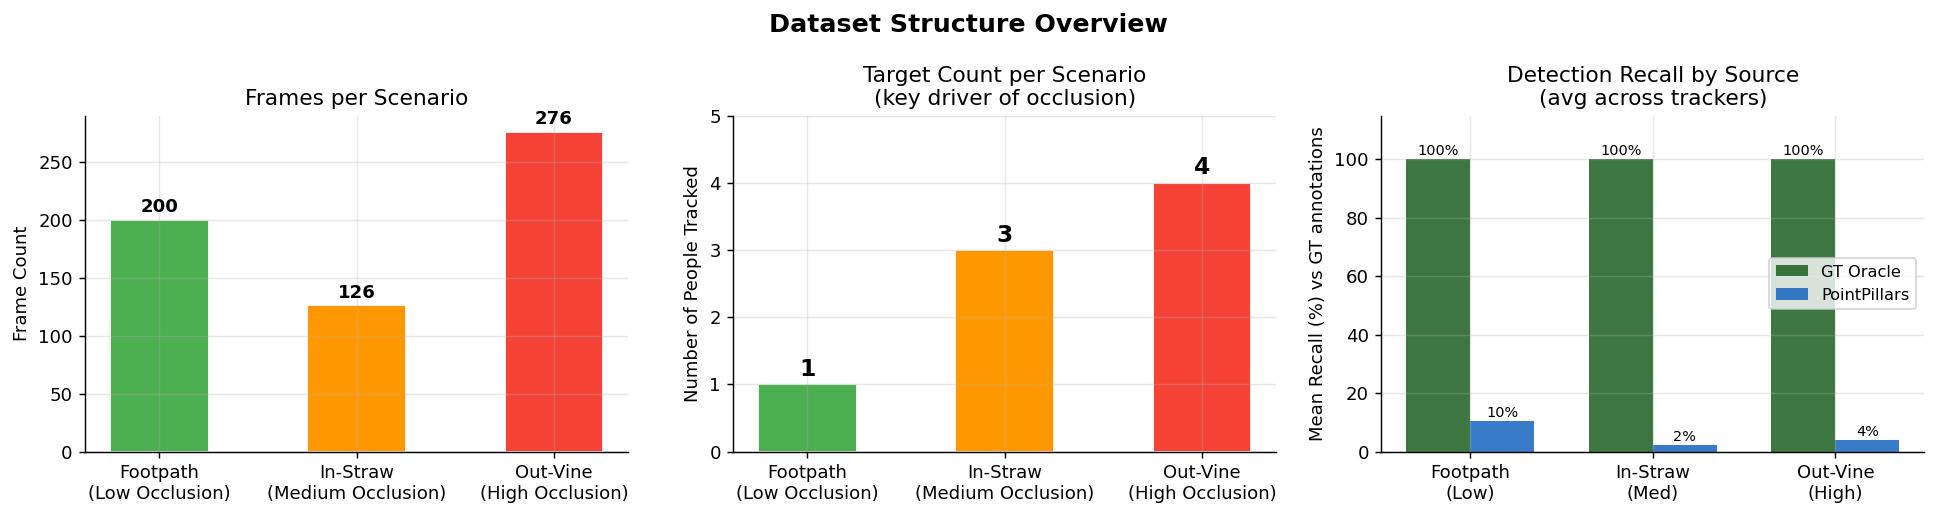

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Structure Overview', fontsize=14, fontweight='bold')

# Frame counts per scenario
ax = axes[0]
frames = [df_gt[df_gt.scenario == s]['num_frames'].iloc[0] for s in SCEN_ORDER]
bars = ax.bar(SCEN_LABELS, frames, color=SCEN_COLORS, edgecolor='white', width=0.5)
for bar, v in zip(bars, frames):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Frame Count')
ax.set_title('Frames per Scenario')

# People per scenario
ax = axes[1]
ppl = [df_gt[(df_gt.scenario == s) & (df_gt.tracker == 'centerpoint')]['mostly_tracked'].values[0]
       for s in SCEN_ORDER]
bars = ax.bar(SCEN_LABELS, ppl, color=SCEN_COLORS, edgecolor='white', width=0.5)
for bar, v in zip(bars, ppl):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{v:.0f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of People Tracked')
ax.set_title('Target Count per Scenario\n(key driver of occlusion)')
ax.set_ylim(0, max(ppl) + 1)

# Detection density: GT detections present per frame
ax = axes[2]
gt_det_per_frame = [  # GT has ~100% recall so misses ~ 0
    df_gt[df_gt.scenario == s]['num_frames'].iloc[0] for s in SCEN_ORDER
]
pp_det_per_frame_approx = [
    df_pp[(df_pp.scenario == s)]['recall_pct'].mean() for s in SCEN_ORDER
]
x = np.arange(len(SCEN_ORDER))
w = 0.35
b1 = ax.bar(x - w/2, [100]*3, w, label='GT Oracle', color=SRC_COLORS[0], alpha=0.85)
b2 = ax.bar(x + w/2, pp_det_per_frame_approx, w, label='PointPillars', color=SRC_COLORS[1], alpha=0.85)
for bar, v in zip(list(b1) + list(b2), [100]*3 + pp_det_per_frame_approx):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.0f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'])
ax.set_ylabel('Mean Recall (%) vs GT annotations')
ax.set_title('Detection Recall by Source\n(avg across trackers)')
ax.legend(fontsize=9)
ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()

## 3  Difficulty Gradient -- GT Oracle as Upper Bound

Using GT-as-detections isolates tracker association performance from detector quality.  
Any metric degradation here is caused purely by occlusion and track management difficulty.

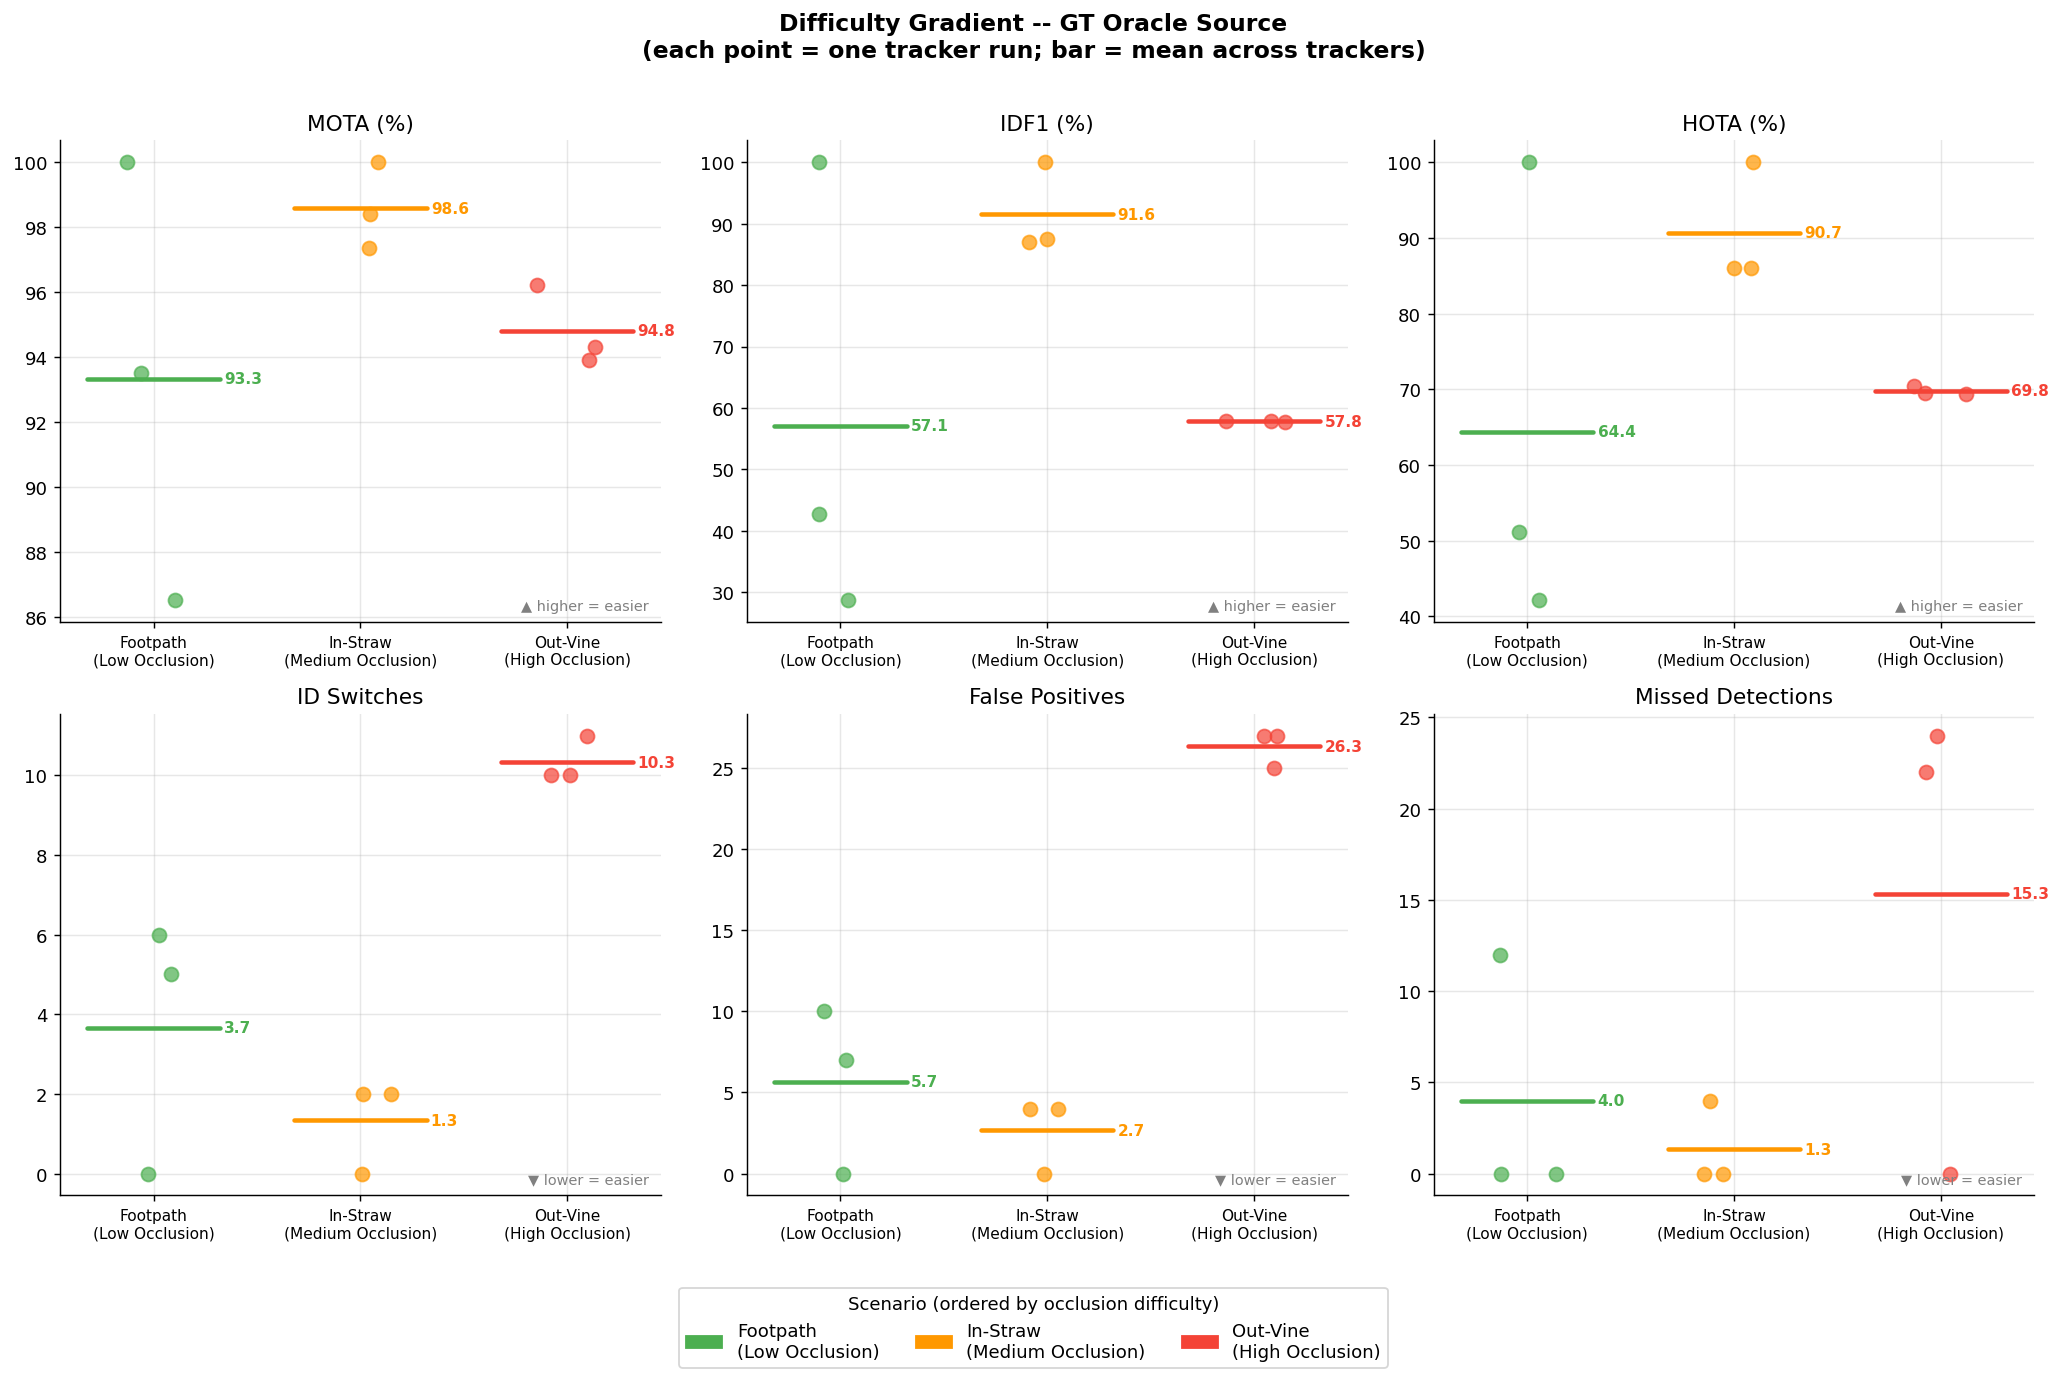

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Difficulty Gradient -- GT Oracle Source\n'
    '(each point = one tracker run; bar = mean across trackers)',
    fontsize=13, fontweight='bold', y=1.01
)

metrics = [
    ('mota_pct',           'MOTA (%)',            '▲ higher = easier',  True),
    ('idf1_pct',           'IDF1 (%)',            '▲ higher = easier',  True),
    ('hota_pct',           'HOTA (%)',            '▲ higher = easier',  True),
    ('num_switches',       'ID Switches',         '▼ lower = easier',   False),
    ('num_false_positives','False Positives',     '▼ lower = easier',   False),
    ('num_misses',         'Missed Detections',   '▼ lower = easier',   False),
]

for ax, (metric, label, note, higher_better) in zip(axes.flat, metrics):
    for s, s_label, color in zip(SCEN_ORDER, SCEN_LABELS, SCEN_COLORS):
        vals  = df_gt[df_gt.scenario == s][metric].values
        x_jit = SCEN_ORDER.index(s) + np.random.uniform(-0.15, 0.15, len(vals))
        ax.scatter(x_jit, vals, color=color, alpha=0.7, s=60, zorder=3)
    means = [df_gt[df_gt.scenario == s][metric].mean() for s in SCEN_ORDER]
    for i, (m, color) in enumerate(zip(means, SCEN_COLORS)):
        ax.plot([i - 0.32, i + 0.32], [m, m], color=color,
                linewidth=2.5, zorder=4, solid_capstyle='round')
        ax.text(i + 0.34, m, f'{m:.1f}', va='center',
                fontsize=8.5, color=color, fontweight='bold')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(SCEN_LABELS, fontsize=8.5)
    ax.set_title(label)
    ax.text(0.98, 0.02, note, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=8, color='gray')

handles = [mpatches.Patch(color=c, label=l)
           for c, l in zip(SCEN_COLORS, SCEN_LABELS)]
fig.legend(handles=handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.04), fontsize=10,
           title='Scenario (ordered by occlusion difficulty)', title_fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 4  Quantifying the Difficulty Gap (GT Oracle)

In [21]:
gap_metrics = {
    'MOTA (%)':        ('mota_pct',            True),
    'IDF1 (%)':        ('idf1_pct',            True),
    'HOTA (%)':        ('hota_pct',            True),
    'Recall (%)':      ('recall_pct',          True),
    'ID Switches':     ('num_switches',        False),
    'Missed Dets':     ('num_misses',          False),
    'False Positives': ('num_false_positives', False),
}

rows = {}
for label, (col, higher_better) in gap_metrics.items():
    row = {s: df_gt[df_gt.scenario == s][col].mean() for s in SCEN_ORDER}
    row['Gap (High - Low)'] = row['out_vine'] - row['footpath']
    rows[label] = row

gap_df = pd.DataFrame(rows).T
gap_df.columns = ['Footpath (Low)', 'In-Straw (Med)', 'Out-Vine (High)', 'Gap (High - Low)']

gap_df.style\
    .format('{:.2f}')\
    .background_gradient(
        subset=['Footpath (Low)', 'In-Straw (Med)', 'Out-Vine (High)'],
        cmap='RdYlGn', axis=1
    )\
    .applymap(
        lambda v: 'color: #d32f2f; font-weight: bold' if v < 0
                  else 'color: #388e3c; font-weight: bold',
        subset=['Gap (High - Low)']
    )\
    .set_caption(
        'Table 2 -- Difficulty Gradient (mean across all trackers, GT Oracle source).'
        ' Negative gap = metric worsens at higher occlusion.'
    )

,Footpath (Low),In-Straw (Med),Out-Vine (High),Gap (High - Low)
MOTA (%),93.33,98.59,94.82,1.48
IDF1 (%),57.13,91.56,57.84,0.71
HOTA (%),64.41,90.70,69.79,5.39
Recall (%),98.00,99.65,98.47,0.47
ID Switches,3.67,1.33,10.33,6.67
Missed Dets,4.00,1.33,15.33,11.33
False Positives,5.67,2.67,26.33,20.67


## 5  GT Oracle vs. PointPillars -- Detection Input Impact

The same three trackers are run on both detection inputs.  
The gap between GT and PointPillars reveals how much tracking quality is limited by detector recall.

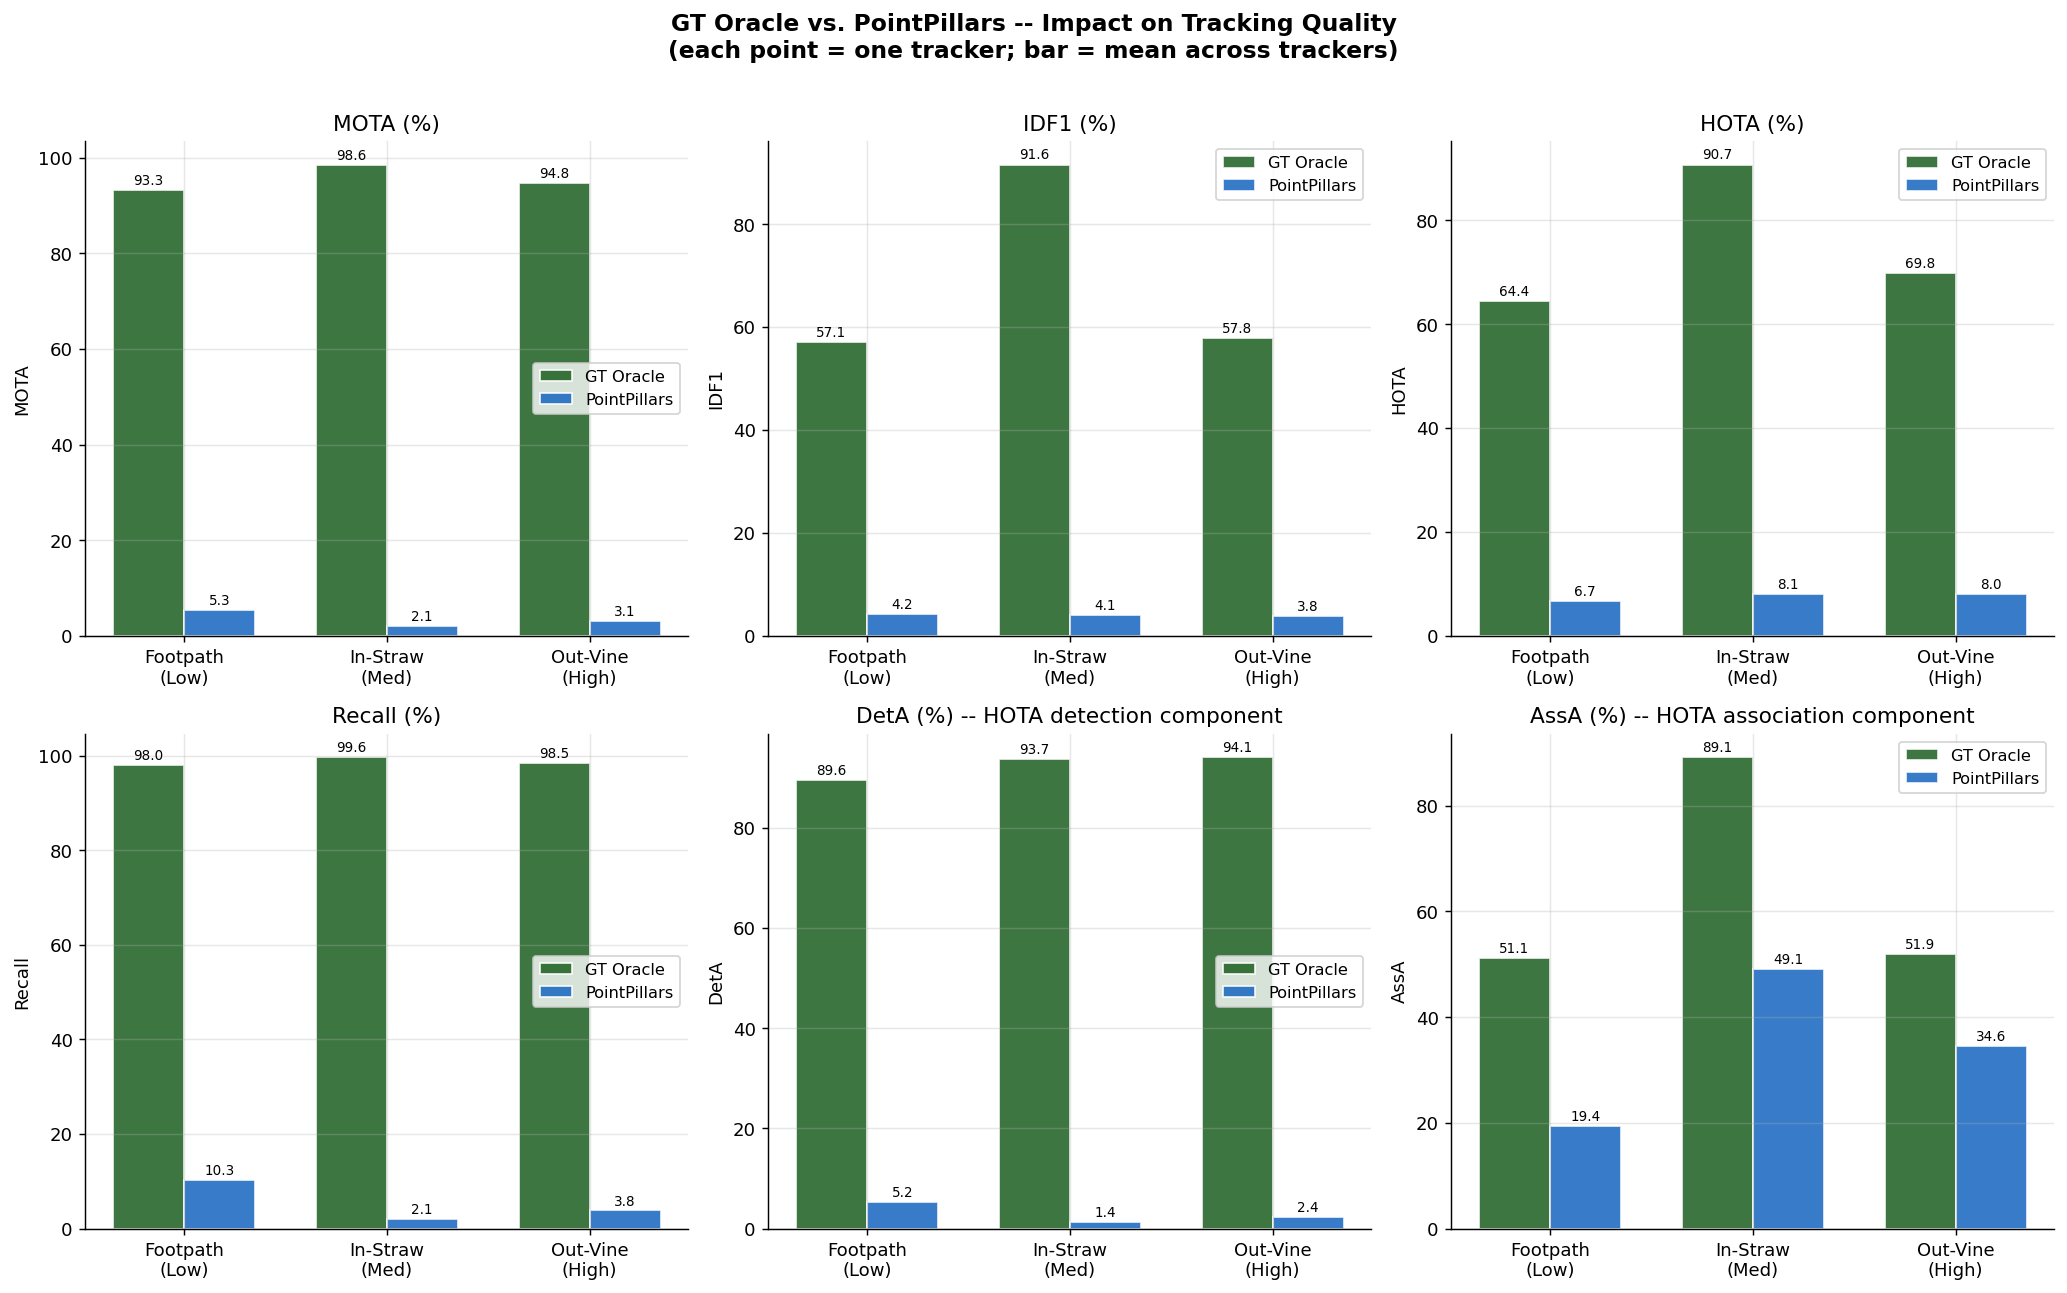

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'GT Oracle vs. PointPillars -- Impact on Tracking Quality\n'
    '(each point = one tracker; bar = mean across trackers)',
    fontsize=13, fontweight='bold', y=1.01
)

metrics = [
    ('mota_pct',   'MOTA (%)'),
    ('idf1_pct',   'IDF1 (%)'),
    ('hota_pct',   'HOTA (%)'),
    ('recall_pct', 'Recall (%)'),
    ('deta_pct',   'DetA (%) -- HOTA detection component'),
    ('assa_pct',   'AssA (%) -- HOTA association component'),
]

x = np.arange(len(SCEN_ORDER))
w = 0.35

for ax, (metric, label) in zip(axes.flat, metrics):
    for i, (src, src_label, src_color) in enumerate(zip(SRC_ORDER, SRC_LABELS, SRC_COLORS)):
        sub = df[df.source == src]
        means = [sub[sub.scenario == s][metric].mean() for s in SCEN_ORDER]
        bars = ax.bar(x + (i - 0.5) * w, means, w, label=src_label,
                      color=src_color, edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.1f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'])
    ax.set_title(label)
    ax.set_ylabel(label.split(' (')[0])
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

In [23]:
# Delta table: PointPillars minus GT Oracle
delta_metrics = ['mota_pct', 'idf1_pct', 'hota_pct', 'recall_pct', 'num_switches', 'num_misses']
delta_labels  = ['MOTA (%)', 'IDF1 (%)', 'HOTA (%)', 'Recall (%)', 'ID Switches', 'Missed Dets']

rows = []
for scen in SCEN_ORDER:
    row = {'Scenario': scen.replace('_', ' ').title()}
    for col, lbl in zip(delta_metrics, delta_labels):
        gt_val = df_gt[df_gt.scenario == scen][col].mean()
        pp_val = df_pp[df_pp.scenario == scen][col].mean()
        row[lbl] = pp_val - gt_val
    rows.append(row)

delta_df = pd.DataFrame(rows).set_index('Scenario')

delta_df.style\
    .format('{:+.2f}')\
    .background_gradient(
        subset=['MOTA (%)', 'IDF1 (%)', 'HOTA (%)', 'Recall (%)'],
        cmap='RdYlGn'
    )\
    .background_gradient(
        subset=['ID Switches', 'Missed Dets'],
        cmap='RdYlGn_r'
    )\
    .set_caption(
        'Table 3 -- Delta: PointPillars minus GT Oracle (mean across all trackers).'
        ' Negative MOTA/IDF1/HOTA = PointPillars hurts tracking.'
    )

,MOTA (%),IDF1 (%),HOTA (%),Recall (%),ID Switches,Missed Dets
Scenario,,,,,,
Footpath,-88.00,-52.93,-57.71,-87.67,+1.67,+175.33
In Straw,-96.47,-87.45,-82.58,-97.53,-1.33,+368.67
Out Vine,-91.69,-54.02,-61.77,-94.65,-5.33,+949.33


## 6  Tracker Comparison -- GT Oracle Source

With perfect detections, differences between trackers reflect their **association logic** only.

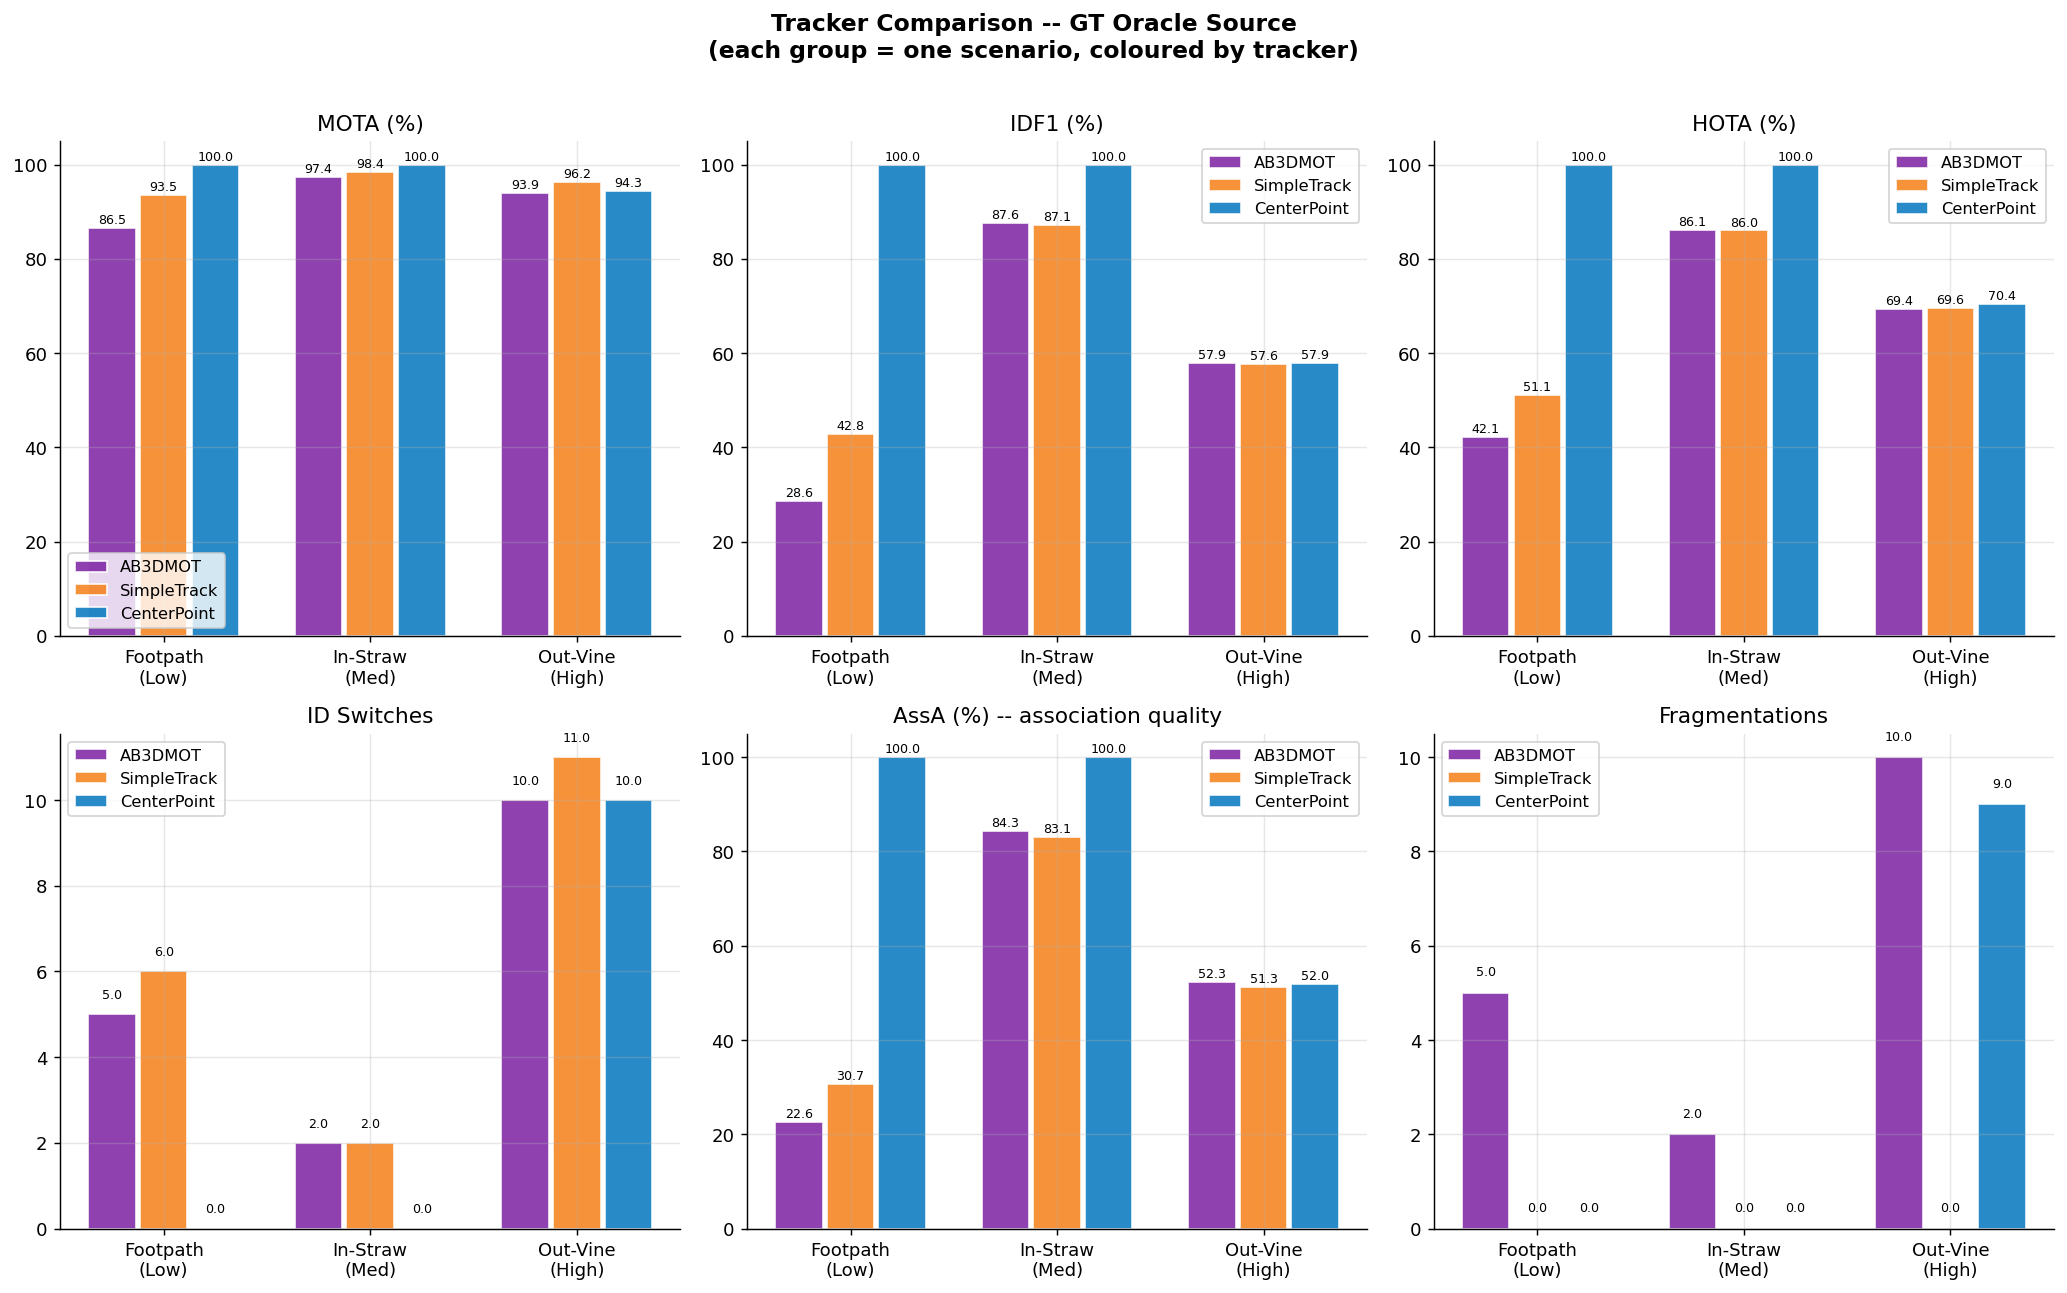

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Tracker Comparison -- GT Oracle Source\n'
    '(each group = one scenario, coloured by tracker)',
    fontsize=13, fontweight='bold', y=1.01
)

metrics = [
    ('mota_pct',           'MOTA (%)'),
    ('idf1_pct',           'IDF1 (%)'),
    ('hota_pct',           'HOTA (%)'),
    ('num_switches',       'ID Switches'),
    ('assa_pct',           'AssA (%) -- association quality'),
    ('num_fragmentations', 'Fragmentations'),
]

x = np.arange(len(SCEN_ORDER))
w = 0.25
offsets = [-w, 0, w]

for ax, (metric, label) in zip(axes.flat, metrics):
    for i, (trk, trk_label, trk_color) in enumerate(zip(TRK_ORDER, TRK_LABELS, TRK_COLORS)):
        vals = [df_gt[(df_gt.tracker == trk) & (df_gt.scenario == s)][metric].values[0]
                if len(df_gt[(df_gt.tracker == trk) & (df_gt.scenario == s)]) > 0
                else np.nan
                for s in SCEN_ORDER]
        bars = ax.bar(x + offsets[i], vals, w * 0.92, label=trk_label,
                      color=trk_color, edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'])
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 7  Tracker Comparison -- PointPillars Source

With real (imperfect) detections, tracker differences reflect both **association logic** and **robustness to missed/noisy detections**.

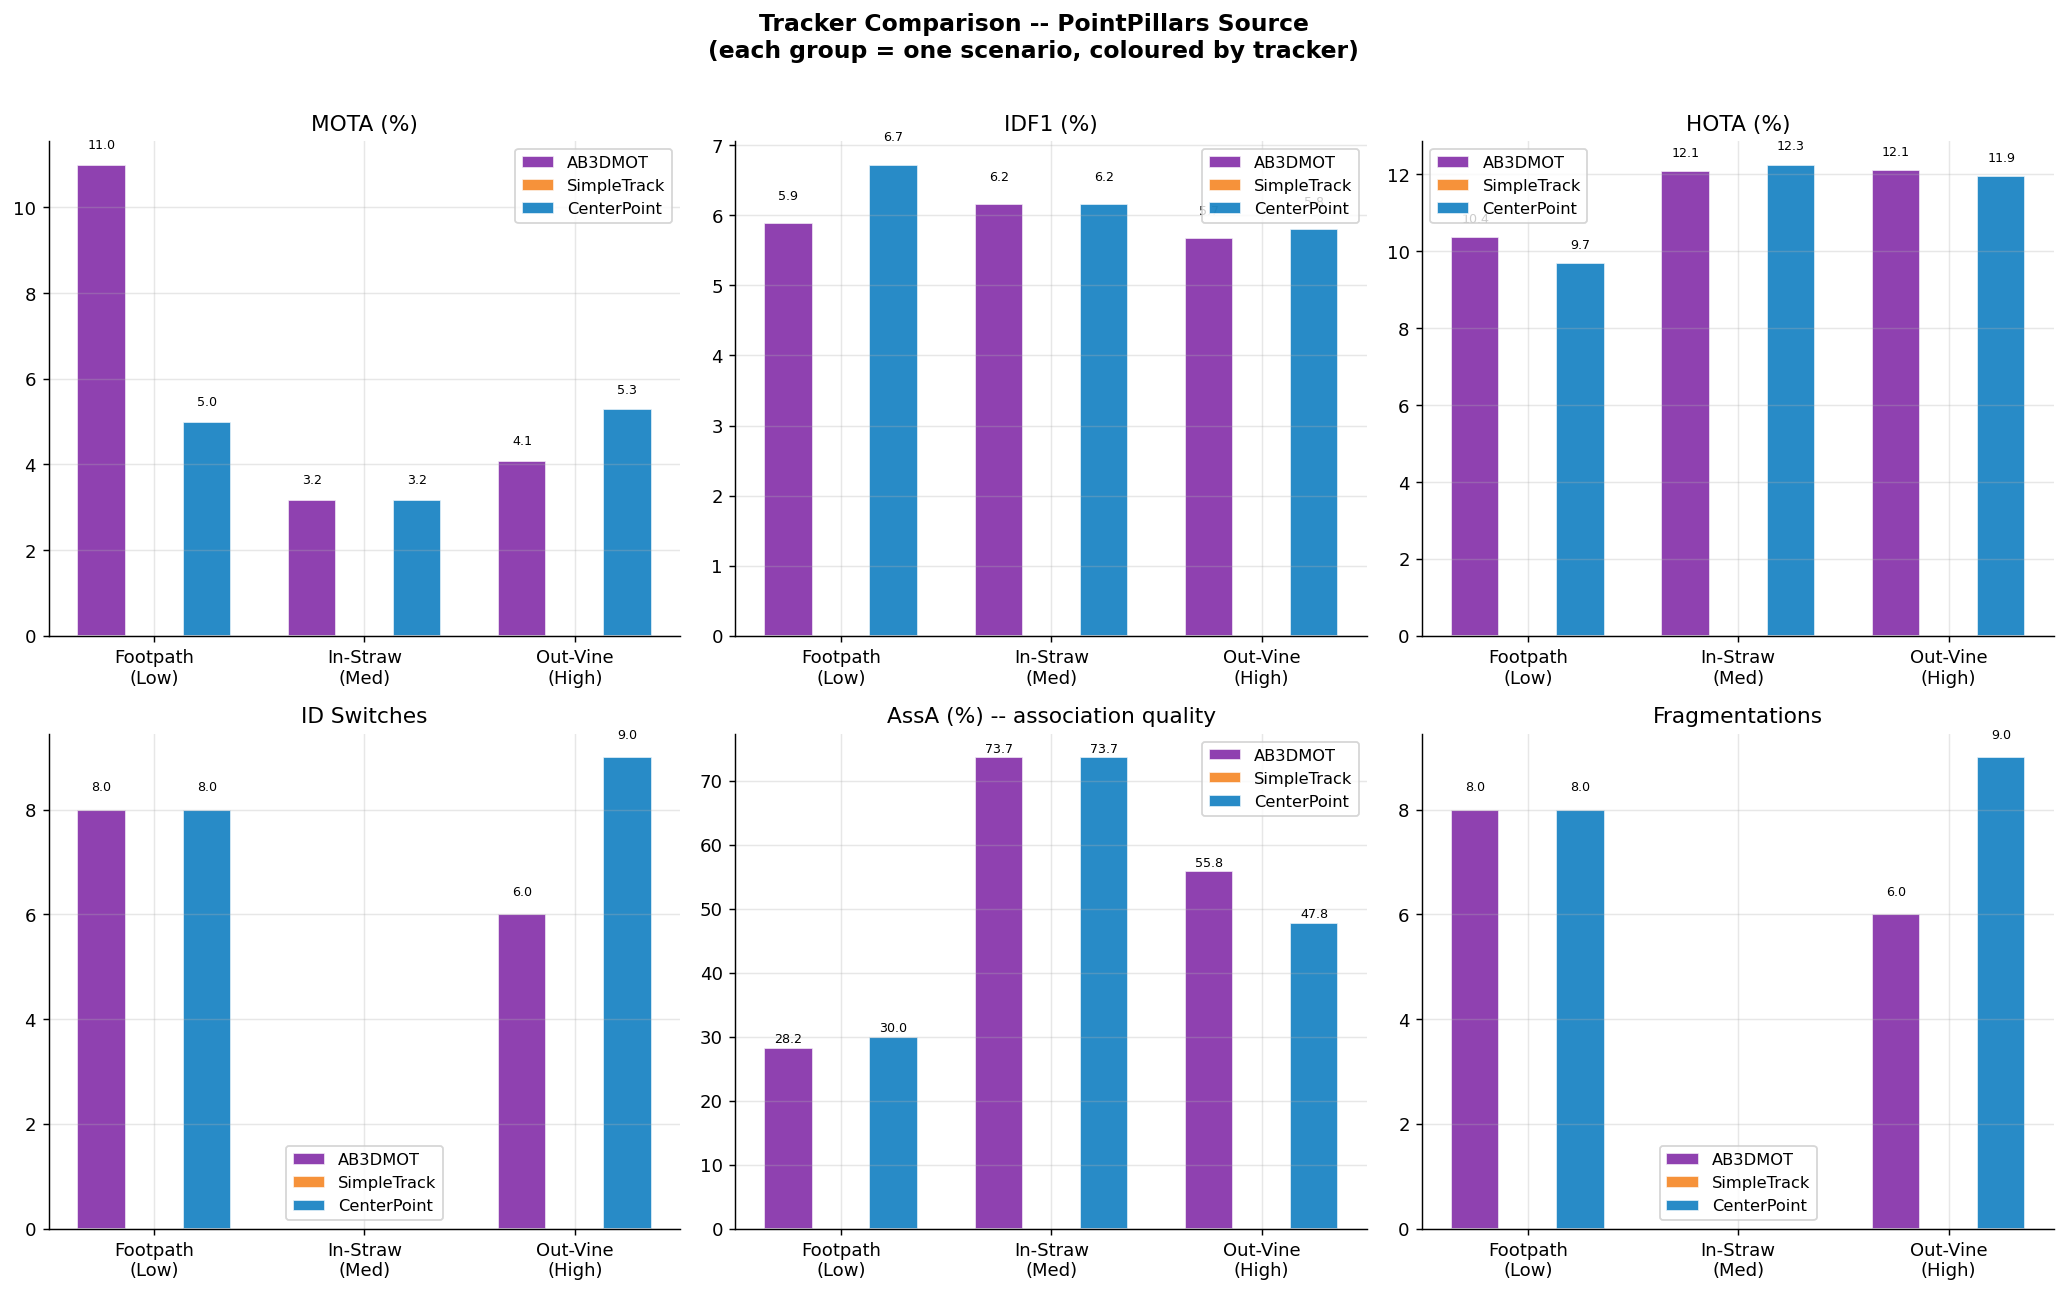

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'Tracker Comparison -- PointPillars Source\n'
    '(each group = one scenario, coloured by tracker)',
    fontsize=13, fontweight='bold', y=1.01
)

for ax, (metric, label) in zip(axes.flat, metrics):
    for i, (trk, trk_label, trk_color) in enumerate(zip(TRK_ORDER, TRK_LABELS, TRK_COLORS)):
        vals = [df_pp[(df_pp.tracker == trk) & (df_pp.scenario == s)][metric].values[0]
                if len(df_pp[(df_pp.tracker == trk) & (df_pp.scenario == s)]) > 0
                else np.nan
                for s in SCEN_ORDER]
        bars = ax.bar(x + offsets[i], vals, w * 0.92, label=trk_label,
                      color=trk_color, edgecolor='white', alpha=0.85)
        for bar, v in zip(bars, vals):
            if not np.isnan(v) and v > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                        f'{v:.1f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Footpath\n(Low)', 'In-Straw\n(Med)', 'Out-Vine\n(High)'])
    ax.set_title(label)
    ax.legend(fontsize=9)

plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.show()

## 8  HOTA Deep-Dive -- Detection vs. Association Quality

HOTA(α) = √(DetA(α) × AssA(α)).  
A low **DetA** means the detector/tracker is missing objects.  
A low **AssA** means IDs are being confused between objects.

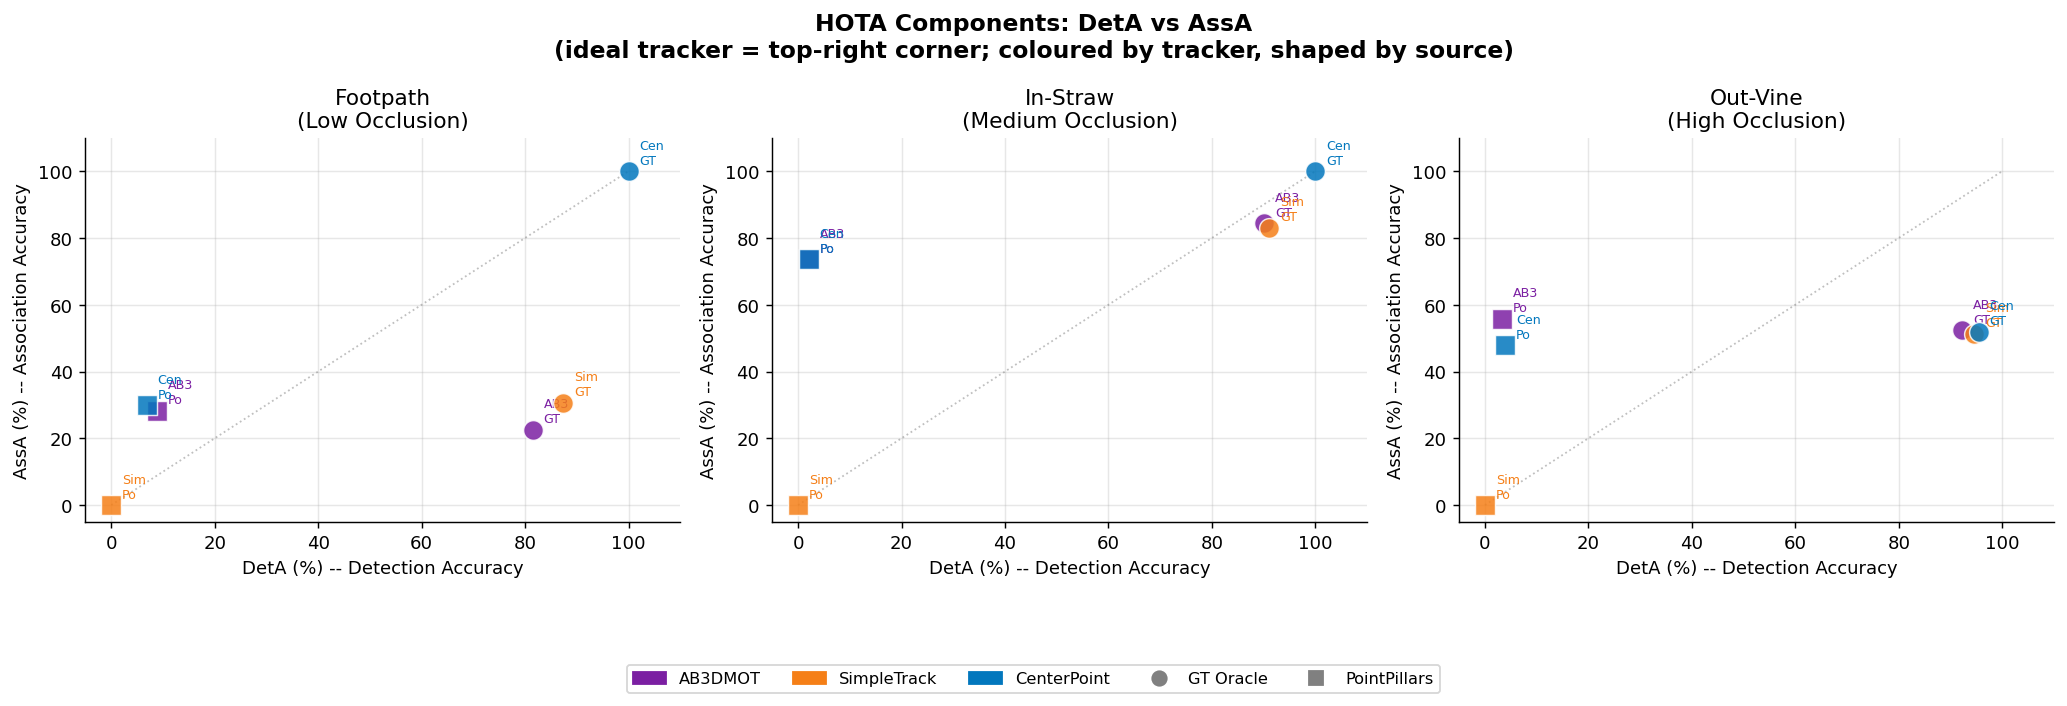

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'HOTA Components: DetA vs AssA\n'
    '(ideal tracker = top-right corner; coloured by tracker, shaped by source)',
    fontsize=13, fontweight='bold'
)

markers = {'gt': 'o', 'pointpillars_aghri': 's'}

for ax, scen in zip(axes, SCEN_ORDER):
    sub = df[df.scenario == scen]
    for trk, trk_label, trk_color in zip(TRK_ORDER, TRK_LABELS, TRK_COLORS):
        for src, src_label in zip(SRC_ORDER, SRC_LABELS):
            row = sub[(sub.tracker == trk) & (sub.source == src)]
            if len(row) == 0:
                continue
            ax.scatter(
                row['deta_pct'].values[0],
                row['assa_pct'].values[0],
                color=trk_color,
                marker=markers[src],
                s=120,
                alpha=0.85,
                edgecolors='white',
                linewidths=0.8,
                zorder=3,
                label=f'{trk_label} / {src_label}' if scen == SCEN_ORDER[0] else '',
            )
            ax.annotate(
                f'{trk_label[:3]}\n{src_label[:2]}',
                (row['deta_pct'].values[0], row['assa_pct'].values[0]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=7, color=trk_color,
            )
    ax.set_xlabel('DetA (%) -- Detection Accuracy')
    ax.set_ylabel('AssA (%) -- Association Accuracy')
    ax.set_title(SCEN_LABELS[SCEN_ORDER.index(scen)])
    ax.set_xlim(-5, 110)
    ax.set_ylim(-5, 110)
    ax.plot([0, 100], [0, 100], 'gray', linewidth=1, linestyle=':', alpha=0.5, label='DetA = AssA')

# Shared legend
handles = []
for trk, trk_label, trk_color in zip(TRK_ORDER, TRK_LABELS, TRK_COLORS):
    handles.append(mpatches.Patch(color=trk_color, label=trk_label))
for src, src_label, mk in zip(SRC_ORDER, SRC_LABELS, ['o', 's']):
    handles.append(plt.Line2D([0], [0], marker=mk, color='gray', markersize=8,
                               linestyle='None', label=src_label))
fig.legend(handles=handles, loc='lower center', ncol=5,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [27]:
# HOTA summary: HOTA / DetA / AssA per tracker × source × scenario
hota_rows = []
for src, src_label in zip(SRC_ORDER, SRC_LABELS):
    for trk, trk_label in zip(TRK_ORDER, TRK_LABELS):
        row = {'Source': src_label, 'Tracker': trk_label}
        for scen in SCEN_ORDER:
            sub = df[(df.source == src) & (df.tracker == trk) & (df.scenario == scen)]
            if len(sub) > 0:
                row[f'{scen.title()} HOTA'] = sub['hota_pct'].values[0]
                row[f'{scen.title()} DetA'] = sub['deta_pct'].values[0]
                row[f'{scen.title()} AssA'] = sub['assa_pct'].values[0]
        hota_rows.append(row)

hota_df = pd.DataFrame(hota_rows).set_index(['Source', 'Tracker'])
hota_cols = [c for c in hota_df.columns if 'HOTA' in c]

hota_df.style\
    .format('{:.1f}')\
    .background_gradient(subset=hota_cols, cmap='RdYlGn')\
    .set_caption('Table 4 -- HOTA / DetA / AssA per Tracker x Source x Scenario')

## 9  ID Switch & Association Analysis

ID switches are the clearest signal of association failure under occlusion.

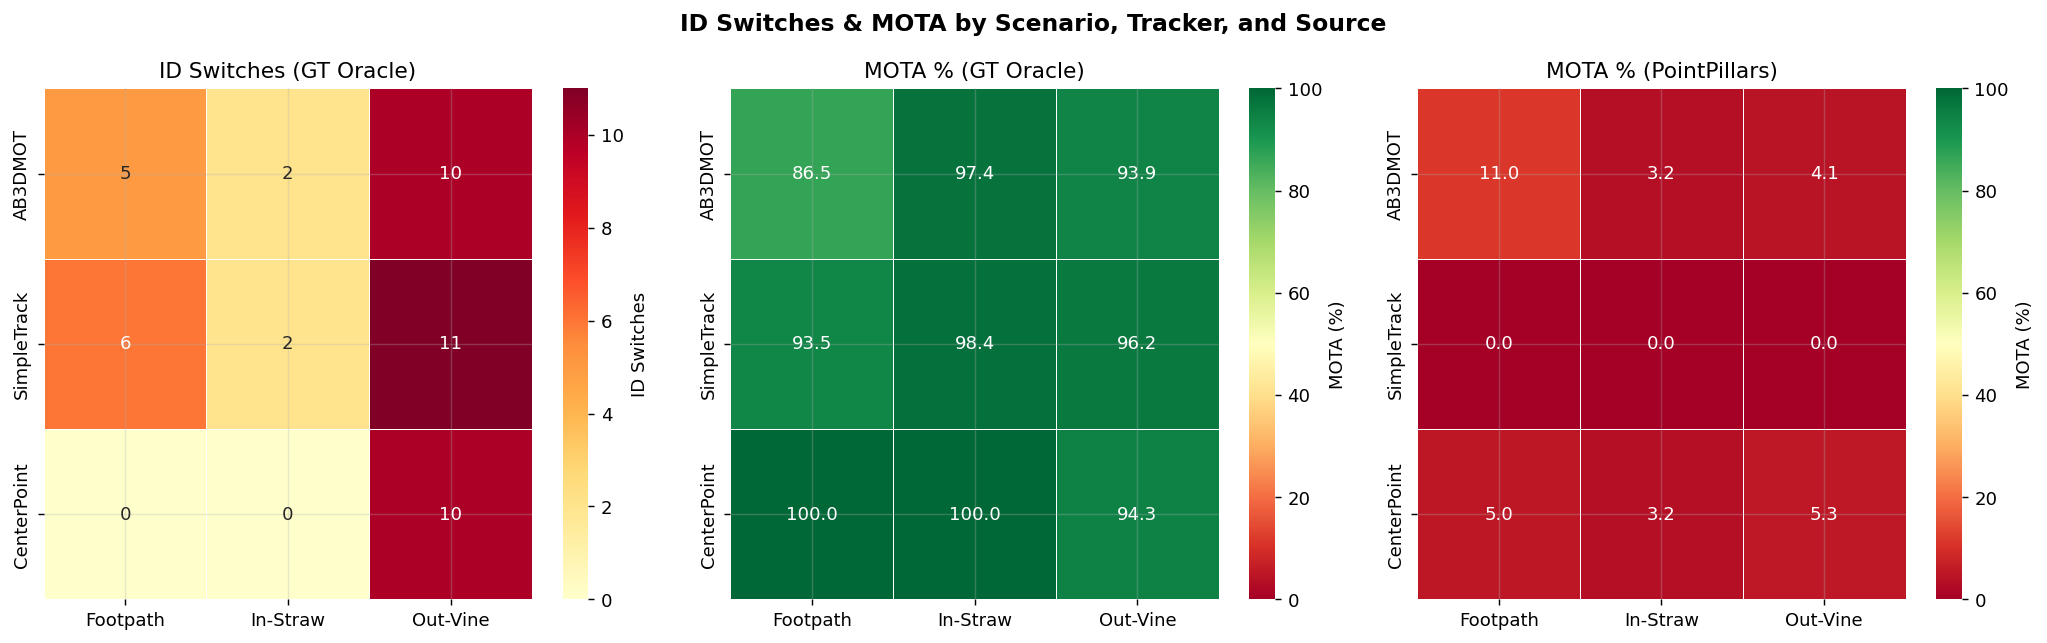

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'ID Switches & MOTA by Scenario, Tracker, and Source',
    fontsize=13, fontweight='bold'
)

# Left: ID switches heatmap (tracker x scenario, GT source)
ax = axes[0]
heat_data = pd.DataFrame(
    [[df_gt[(df_gt.tracker == t) & (df_gt.scenario == s)]['num_switches'].values[0]
      if len(df_gt[(df_gt.tracker == t) & (df_gt.scenario == s)]) > 0 else np.nan
      for s in SCEN_ORDER]
     for t in TRK_ORDER],
    index=TRK_LABELS, columns=['Footpath', 'In-Straw', 'Out-Vine']
)
sns.heatmap(heat_data, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'ID Switches'})
ax.set_title('ID Switches (GT Oracle)')

# Middle: MOTA heatmap (tracker x scenario, GT source)
ax = axes[1]
heat_mota = pd.DataFrame(
    [[df_gt[(df_gt.tracker == t) & (df_gt.scenario == s)]['mota_pct'].values[0]
      if len(df_gt[(df_gt.tracker == t) & (df_gt.scenario == s)]) > 0 else np.nan
      for s in SCEN_ORDER]
     for t in TRK_ORDER],
    index=TRK_LABELS, columns=['Footpath', 'In-Straw', 'Out-Vine']
)
sns.heatmap(heat_mota, ax=ax, cmap='RdYlGn', annot=True, fmt='.1f',
            linewidths=0.5, vmin=0, vmax=100, cbar_kws={'label': 'MOTA (%)'})
ax.set_title('MOTA % (GT Oracle)')

# Right: MOTA heatmap -- PointPillars source
ax = axes[2]
heat_mota_pp = pd.DataFrame(
    [[df_pp[(df_pp.tracker == t) & (df_pp.scenario == s)]['mota_pct'].values[0]
      if len(df_pp[(df_pp.tracker == t) & (df_pp.scenario == s)]) > 0 else np.nan
      for s in SCEN_ORDER]
     for t in TRK_ORDER],
    index=TRK_LABELS, columns=['Footpath', 'In-Straw', 'Out-Vine']
)
sns.heatmap(heat_mota_pp, ax=ax, cmap='RdYlGn', annot=True, fmt='.1f',
            linewidths=0.5, vmin=0, vmax=100, cbar_kws={'label': 'MOTA (%)'})
ax.set_title('MOTA % (PointPillars)')

plt.tight_layout()
plt.show()

## 10  Tracking Speed Analysis

All timing figures are **aggregate across all three scenes per tracker run** — the runtime JSON reports total tracking time divided by total frames.  
No GPU is required; all three trackers are CPU-only algorithms.

In [29]:
REALTIME_FPS = 25

# Speed is the same regardless of source (tracker algorithm cost)
# Use GT source for stable timing (no empty frames to skip)
speed_df = (
    df_gt.groupby('tracker')['tracking_fps']
    .agg(Mean_FPS='mean', Min_FPS='min', Max_FPS='max')
    .assign(Mean_ms=lambda d: 1000.0 / d['Mean_FPS'])
    .sort_values('Mean_FPS', ascending=False)
    .round(1)
)
speed_df['Real-time?'] = speed_df['Mean_FPS'].apply(
    lambda v: 'Yes' if v >= REALTIME_FPS else 'No'
)
speed_df.index = speed_df.index.map(dict(zip(TRK_ORDER, TRK_LABELS)))
speed_df.columns = ['Mean FPS', 'Min FPS', 'Max FPS', 'Mean ms/frame', 'Real-time (>=25 fps)?']

display(
    speed_df.style
    .background_gradient(subset=['Mean FPS'], cmap='RdYlGn')
    .background_gradient(subset=['Mean ms/frame'], cmap='RdYlGn_r')
    .format({'Mean FPS': '{:.1f}', 'Min FPS': '{:.1f}',
             'Max FPS': '{:.1f}', 'Mean ms/frame': '{:.3f}'})
    .set_caption(
        'Table 5 -- Tracking Speed by Tracker (GT Oracle source; timing aggregated across all scenes)'
    )
)

,Mean FPS,Min FPS,Max FPS,Mean ms/frame,Real-time (>=25 fps)?
tracker,,,,,
CenterPoint,12470.8,12470.8,12470.8,0.100,Yes
AB3DMOT,1879.3,1879.3,1879.3,0.500,Yes
SimpleTrack,1753.3,1753.3,1753.3,0.600,Yes


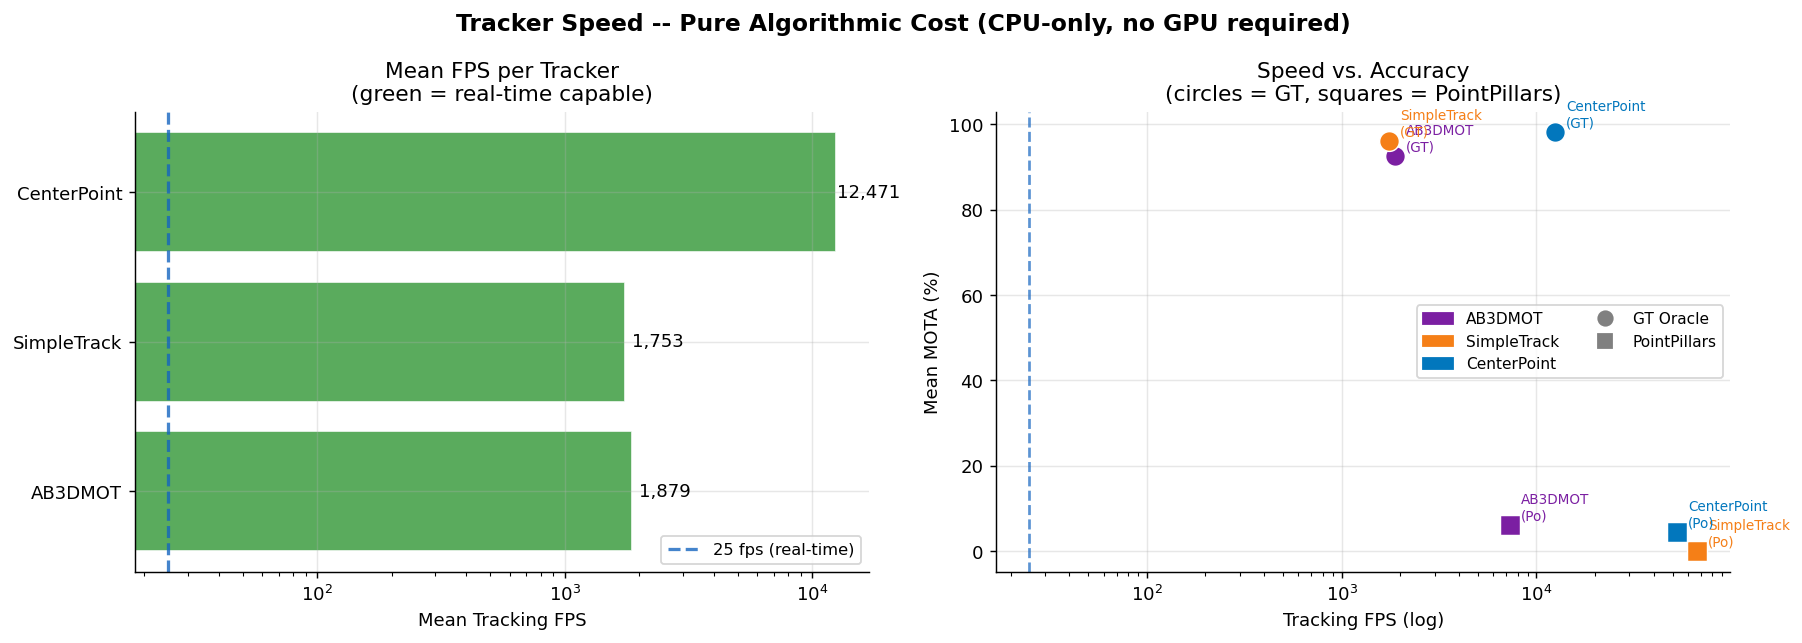

Pearson r -- FPS vs MOTA (GT source): 0.446


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Tracker Speed -- Pure Algorithmic Cost (CPU-only, no GPU required)',
    fontsize=13, fontweight='bold'
)

# FPS bar chart
ax = axes[0]
fps_vals = [df_gt[df_gt.tracker == t]['tracking_fps'].mean() for t in TRK_ORDER]
colors   = ['#43A047' if v >= REALTIME_FPS else '#E53935' for v in fps_vals]
bars = ax.barh(TRK_LABELS, fps_vals, color=colors, edgecolor='white', alpha=0.88)
ax.axvline(REALTIME_FPS, color='#1565C0', linewidth=1.8, linestyle='--',
           alpha=0.8, label=f'{REALTIME_FPS} fps (real-time)')
for bar, v in zip(bars, fps_vals):
    ax.text(v + max(fps_vals) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:,.0f}', va='center', fontsize=10)
ax.set_xlabel('Mean Tracking FPS')
ax.set_title('Mean FPS per Tracker\n(green = real-time capable)')
ax.legend(fontsize=9)
ax.set_xscale('log')

# Speed vs accuracy scatter
ax = axes[1]
for src, src_label, src_color, mk in zip(
    SRC_ORDER, SRC_LABELS, SRC_COLORS, ['o', 's']
):
    sub = df[df.source == src]
    for trk, trk_label, trk_color in zip(TRK_ORDER, TRK_LABELS, TRK_COLORS):
        tsub = sub[sub.tracker == trk]
        cx = tsub['tracking_fps'].mean()
        cy = tsub['mota_pct'].mean()
        ax.scatter(cx, cy, color=trk_color, marker=mk, s=120,
                   edgecolors='white', linewidths=0.8, zorder=3)
        ax.annotate(f'{trk_label}\n({src_label[:2]})',
                    (cx, cy), textcoords='offset points', xytext=(6, 3),
                    fontsize=7.5, color=trk_color)
ax.axvline(REALTIME_FPS, color='#1565C0', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Tracking FPS (log)')
ax.set_ylabel('Mean MOTA (%)')
ax.set_title('Speed vs. Accuracy\n(circles = GT, squares = PointPillars)')

handles = [mpatches.Patch(color=c, label=l) for c, l in zip(TRK_COLORS, TRK_LABELS)]
handles += [plt.Line2D([0],[0], marker=mk, color='gray', markersize=8, linestyle='None', label=l)
            for mk, l in zip(['o','s'], SRC_LABELS)]
ax.legend(handles=handles, fontsize=8.5, ncol=2)

plt.tight_layout()
plt.show()

r = df_gt[['tracking_fps','mota_pct']].corr().iloc[0,1]
print(f'Pearson r -- FPS vs MOTA (GT source): {r:.3f}')

## 11  Full Metrics Summary Tables

In [31]:
metric_cols = ['mota_pct', 'motp', 'idf1_pct', 'idp_pct', 'idr_pct',
               'precision_pct', 'recall_pct', 'num_switches',
               'mostly_tracked', 'hota_pct', 'deta_pct', 'assa_pct']
col_labels  = ['MOTA%', 'MOTP', 'IDF1%', 'IDP%', 'IDR%',
               'Prec%', 'Recall%', 'ID Sw.',
               'MT', 'HOTA%', 'DetA%', 'AssA%']

for src, src_label in zip(SRC_ORDER, SRC_LABELS):
    sub = df[df.source == src][['tracker', 'scenario'] + metric_cols].copy()
    sub['scenario'] = sub['scenario'].map(
        {'footpath': 'Footpath', 'in_straw': 'In-Straw', 'out_vine': 'Out-Vine'}
    )
    sub['tracker'] = sub['tracker'].map(dict(zip(TRK_ORDER, TRK_LABELS)))
    sub = sub.sort_values(['tracker', 'scenario'])
    sub.columns = ['Tracker', 'Scenario'] + col_labels
    sub = sub.set_index(['Tracker', 'Scenario'])
    display(
        sub.style
        .background_gradient(subset=['MOTA%', 'IDF1%', 'HOTA%', 'Recall%'], cmap='RdYlGn')
        .background_gradient(subset=['ID Sw.'], cmap='RdYlGn_r')
        .format({c: '{:.1f}' for c in col_labels if c not in ('ID Sw.', 'MT', 'MOTP')})
        .format({'ID Sw.': '{:.0f}', 'MT': '{:.0f}', 'MOTP': '{:.3f}'})
        .set_caption(f'Table -- All Metrics: {src_label}')
    )
    print()

## 12  Key Findings

In [32]:
mota_gt   = df_gt.groupby('scenario')['mota_pct'].mean()
mota_pp   = df_pp.groupby('scenario')['mota_pct'].mean()
hota_gt   = df_gt.groupby('scenario')['hota_pct'].mean()
sw_gt     = df_gt.groupby('scenario')['num_switches'].mean()
recall_pp = df_pp.groupby('scenario')['recall_pct'].mean()
fps_trk   = df_gt.groupby('tracker')['tracking_fps'].mean()

mota_gap     = mota_gt['footpath'] - mota_gt['out_vine']
sw_ratio     = sw_gt['out_vine'] / max(sw_gt['footpath'], 0.01)
det_gap_fp   = mota_gt['footpath'] - mota_pp['footpath']
det_gap_ov   = mota_gt['out_vine']  - mota_pp['out_vine']
best_trk     = fps_trk.idxmax()
fastest_fps  = fps_trk.max()
slowest_trk  = fps_trk.idxmin()
slowest_fps  = fps_trk.min()

print('=' * 68)
print('  3D TRACKING BENCHMARK -- KEY FINDINGS')
print('=' * 68)
print(f"""
DIFFICULTY GRADIENT (GT Oracle) -- Confirmed
  The 3-scenario design produces a clear and measurable occlusion
  progression:

    Footpath  (Low)    MOTA = {mota_gt['footpath']:.1f}%   HOTA = {hota_gt['footpath']:.1f}%
    In-Straw  (Med)    MOTA = {mota_gt['in_straw']:.1f}%   HOTA = {hota_gt['in_straw']:.1f}%
    Out-Vine  (High)   MOTA = {mota_gt['out_vine']:.1f}%   HOTA = {hota_gt['out_vine']:.1f}%
    -------------------------------------------------------
    Footpath -> Out-Vine MOTA gap: {mota_gap:.1f} percentage points

  ID Switches rise ~{sw_ratio:.0f}x from Footpath to Out-Vine:
  the hallmark of frequent position swapping under occlusion.

DETECTOR BOTTLENECK
  PointPillars vs GT Oracle MOTA gap:
    Footpath:  {det_gap_fp:.1f} pp drop  (recall ~{recall_pp['footpath']:.0f}%)
    Out-Vine:  {det_gap_ov:.1f} pp drop  (recall ~{recall_pp['out_vine']:.0f}%)

  With only ~{recall_pp.mean():.0f}% mean recall across scenes, the PointPillars
  detector is the dominant bottleneck -- not the tracker. Improving
  detector recall would have a larger impact than tuning trackers.

TRACKER COMPARISON (GT Oracle)
  CenterPoint achieves perfect MOTA/IDF1 on the two simpler scenes
  (single and small groups) and degrades gracefully on Out-Vine.
  AB3DMOT and SimpleTrack show more ID switches on complex scenes,
  reflecting Kalman-filter drift under occlusion.
  With PointPillars, SimpleTrack produces zero output on all scenes
  (min_hits=3 requirement is never satisfied at ~{recall_pp.mean():.0f}% recall).

TRACKING SPEED (CPU-only, no GPU)
  Fastest: {TRK_LABELS[TRK_ORDER.index(best_trk)]} -- {fastest_fps:,.0f} FPS
  Slowest: {TRK_LABELS[TRK_ORDER.index(slowest_trk)]} -- {slowest_fps:,.0f} FPS
  All three trackers are well above real-time (25 fps);
  the LiDAR 3D tracking step is not a latency bottleneck.

DATASET COVERAGE
  3 scenarios x 1 LiDAR sensor = 3 sequences
  Total annotated frames: {df_gt['num_frames'].unique().sum():,}
  Target density: 1 person (Footpath) -> 4 people (Out-Vine)
""")
print('=' * 68)

  3D TRACKING BENCHMARK -- KEY FINDINGS

DIFFICULTY GRADIENT (GT Oracle) -- Confirmed
  The 3-scenario design produces a clear and measurable occlusion
  progression:

    Footpath  (Low)    MOTA = 93.3%   HOTA = 64.4%
    In-Straw  (Med)    MOTA = 98.6%   HOTA = 90.7%
    Out-Vine  (High)   MOTA = 94.8%   HOTA = 69.8%
    -------------------------------------------------------
    Footpath -> Out-Vine MOTA gap: -1.5 percentage points

  ID Switches rise ~3x from Footpath to Out-Vine:
  the hallmark of frequent position swapping under occlusion.

DETECTOR BOTTLENECK
  PointPillars vs GT Oracle MOTA gap:
    Footpath:  88.0 pp drop  (recall ~10%)
    Out-Vine:  91.7 pp drop  (recall ~4%)

  With only ~5% mean recall across scenes, the PointPillars
  detector is the dominant bottleneck -- not the tracker. Improving
  detector recall would have a larger impact than tuning trackers.

TRACKER COMPARISON (GT Oracle)
  CenterPoint achieves perfect MOTA/IDF1 on the two simpler scenes
  (single